<h1 style="color:#48C9B0; border-bottom:2px solid #48C9B0; padding-bottom:10px;">
Notebook 2 - Clustering et analyse semi-supervisée
</h1>

<h4 style="color:#48C9B0;">1. Introduction</h4>
<ul>
    <li>1.1 Contexte</li>
    <li>1.2 Objectifs du notebook</li>
</ul>

<h4 style="color:#48C9B0;">2. Chargement des embeddings</h4>
<ul>
    <li>2.1 Import des librairies</li>
    <li>2.2 Chargement des fichiers .npy</li>
    <li>2.3 Vérification des dimensions</li>
    <li>2.4 Vérification des labels</li>
</ul>

<h4 style="color:#48C9B0;">3. Réduction de dimension</h4>
<ul>
    <li>3.1 Standardisation des embeddings</li>
    <li>3.2 PCA 2D pour visualisation</li>
    <li>3.3 PCA conservant 95 % de variance</li>
    <li>3.4 UMAP pour visualisation non linéaire</li>
</ul>

<h4 style="color:#48C9B0;">4. Clustering non supervisé</h4>
<ul>
    <li>4.1 K-Means</li>
    <li>4.2 Choix du nombre de clusters</li>
    <li>4.3 DBSCAN</li>
    <li>4.4 Comparaison des méthodes</li>
</ul>

<h4 style="color:#48C9B0;">5. Analyse des clusters avec les labels connus</h4>
<ul>
    <li>5.1 Répartition cancer / Normal par cluster</li>
    <li>5.2 Interprétation des clusters</li>
    <li>5.3 Évaluation des clusters (ARI, NMI)</li>
</ul>

<h4 style="color:#48C9B0;">6. Pseudo-labellisation exploratoire</h4>
<ul>
    <li>6.1 Attribution d’un profil probable</li>
    <li>6.2 Analyse des images non labellisées</li>
    <li>6.3 Score de confiance</li>
    <li>6.4 Limites de l’approche</li>
</ul>

<h4 style="color:#48C9B0;">7. Entraînement supervisé et semi-supervisé</h4>
<ul>
    <li>7.1 Préparation des jeux de données</li>
    <li>7.2 Modèle CNN utilisé</li>
    <li>7.3 Entraînement supervisé</li>
    <li>7.4 Entraînement semi-supervisé</li>
    <li>7.5 Évaluation des performances</li>
    <li>7.6 Comparaison supervisé vs semi-supervisé</li>
</ul>

<h4 style="color:#48C9B0;">8. Conclusion</h4>
<ul>
    <li>8.1 Résultats principaux</li>
    <li>8.2 Limites</li>
    <li>8.3 Perspectives et prochaines étapes</li>
</ul>

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">
<b style="color:black;">Objectif</b><br><br>

Dans ce second notebook, j'exploite les embeddings visuels générés dans le premier notebook afin d'analyser la structure du dataset.

L'objectif est d'identifier des groupes naturels d'images à l'aide de méthodes de clustering non supervisé. Les labels connus cancer et Normal ne sont pas utilisés pour entraîner le clustering, mais uniquement comme repères d'interprétation.

Les images non labellisées constituent le cœur de l'analyse : elles permettront d'évaluer si les représentations visuelles extraites par ResNet50 permettent de rapprocher certaines IRM de profils connus.
</div>

<h4 style="color:#48C9B0;">2.1 Import des librairies</h4>

In [1456]:
# ============================================================
# Imports généraux
# ============================================================

from pathlib import Path
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Scikit-learn : prétraitement, réduction, clustering, métriques
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import ConfusionMatrixDisplay

# ============================================================
# PyTorch / torchvision
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image

import umap.umap_ as umap

<h4 style="color:#48C9B0;">2.2 Chargement des fichiers .npy</h4>

In [1457]:
FEATURES_DIR = Path("../data/features")

train_features = np.load(FEATURES_DIR / "train_features.npy")
train_labels = np.load(FEATURES_DIR / "train_labels.npy")

val_features = np.load(FEATURES_DIR / "val_features.npy")
val_labels = np.load(FEATURES_DIR / "val_labels.npy")

test_features = np.load(FEATURES_DIR / "test_features.npy")
test_labels = np.load(FEATURES_DIR / "test_labels.npy")

train_unla_features = np.load(FEATURES_DIR / "train_unla_features.npy")
train_unla_labels = np.load(FEATURES_DIR / "train_unla_labels.npy")

val_unla_features = np.load(FEATURES_DIR / "val_unla_features.npy")
val_unla_labels = np.load(FEATURES_DIR / "val_unla_labels.npy")

test_unla_features = np.load(FEATURES_DIR / "test_unla_features.npy")
test_unla_labels = np.load(FEATURES_DIR / "test_unla_labels.npy")

train_metadata = pd.read_csv(FEATURES_DIR / "train_metadata.csv")
val_metadata = pd.read_csv(FEATURES_DIR / "val_metadata.csv")
test_metadata = pd.read_csv(FEATURES_DIR / "test_metadata.csv")

train_unla_metadata = pd.read_csv(FEATURES_DIR / "train_unla_metadata.csv")
val_unla_metadata = pd.read_csv(FEATURES_DIR / "val_unla_metadata.csv")
test_unla_metadata = pd.read_csv(FEATURES_DIR / "test_unla_metadata.csv")


<h4 style="color:#48C9B0;">2.3 Vérification des dimensions</h4>

In [1458]:
print("train_metadata :", train_metadata.shape)
print("val_metadata :", val_metadata.shape)
print("test_metadata :", test_metadata.shape)

print("train_unla_metadata :", train_unla_metadata.shape)
print("val_unla_metadata :", val_unla_metadata.shape)
print("test_unla_metadata :", test_unla_metadata.shape)

assert len(train_features) == len(train_labels) == len(train_metadata)
assert len(val_features) == len(val_labels) == len(val_metadata)
assert len(test_features) == len(test_labels) == len(test_metadata)

assert len(train_unla_features) == len(train_unla_labels) == len(train_unla_metadata)
assert len(val_unla_features) == len(val_unla_labels) == len(val_unla_metadata)
assert len(test_unla_features) == len(test_unla_labels) == len(test_unla_metadata)


train_metadata : (60, 4)
val_metadata : (20, 4)
test_metadata : (20, 4)
train_unla_metadata : (786, 4)
val_unla_metadata : (262, 4)
test_unla_metadata : (263, 4)


<h4 style="color:#48C9B0;">2.4 Vérification des labels</h4>

In [1459]:
print("Train labels")
print(pd.Series(train_labels).value_counts().sort_index())

print("Validation labels")
print(pd.Series(val_labels).value_counts().sort_index())

print("Test labels")
print(pd.Series(test_labels).value_counts().sort_index())

Train labels
0    30
1    30
Name: count, dtype: int64
Validation labels
0    10
1    10
Name: count, dtype: int64
Test labels
0    10
1    10
Name: count, dtype: int64


<h2 style="color:#48C9B0;">3 Réduction de dimension</h2>

<h4 style="color:#48C9B0;">3.1 Standardisation des embeddings</h4>

In [1460]:
# # Analyse de la dispersion des embeddings

# #information
# feature_std = all_features.std(axis=0)

# print("Std min :", feature_std.min())
# print("Std max :", feature_std.max())
# print("Ratio max/min :", feature_std.max() / feature_std.min())

# plt.figure(figsize=(10,5))

# plt.hist(
#     feature_std,
#     bins=50
# )

# plt.xlabel("Écart-type")
# plt.ylabel("Nombre de features")
# plt.title("Distribution des écarts-types des embeddings")

# plt.show()

L'analyse de la distribution des écarts-types montre que les embeddings extraits par ResNet50 présentent une dispersion globalement homogène, mais certaines dimensions possèdent une variabilité plus importante que d'autres. Afin d'éviter qu'un sous-ensemble de caractéristiques influence excessivement la PCA et les algorithmes de clustering basés sur les distances, une standardisation des embeddings est appliquée avant les analyses ultérieures.

In [1461]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)

train_unla_scaled = scaler.transform(train_unla_features)
val_unla_scaled = scaler.transform(val_unla_features)
test_unla_scaled = scaler.transform(test_unla_features)

In [1462]:
print("Moyenne globale :", train_scaled.mean())
print("Std globale :", train_scaled.std())

Moyenne globale : -7.4505807e-10
Std globale : 1.0


<h4 style="color:#48C9B0;">3.2 PCA 2D pour visualisation</h4>

In [1463]:
# ============================================================
# PCA 2D sans fuite de données
# PCA apprise uniquement sur le train labellisé
# ============================================================

pca_2d = PCA(n_components=2, random_state=42)

train_pca_2d = pca_2d.fit_transform(train_scaled)
val_pca_2d = pca_2d.transform(val_scaled)
test_pca_2d = pca_2d.transform(test_scaled)

train_unla_pca_2d = pca_2d.transform(train_unla_scaled)
val_unla_pca_2d = pca_2d.transform(val_unla_scaled)
test_unla_pca_2d = pca_2d.transform(test_unla_scaled)

print("Variance expliquée PCA 2D :", pca_2d.explained_variance_ratio_.sum())

Variance expliquée PCA 2D : 0.2174351


Visualisation PCA

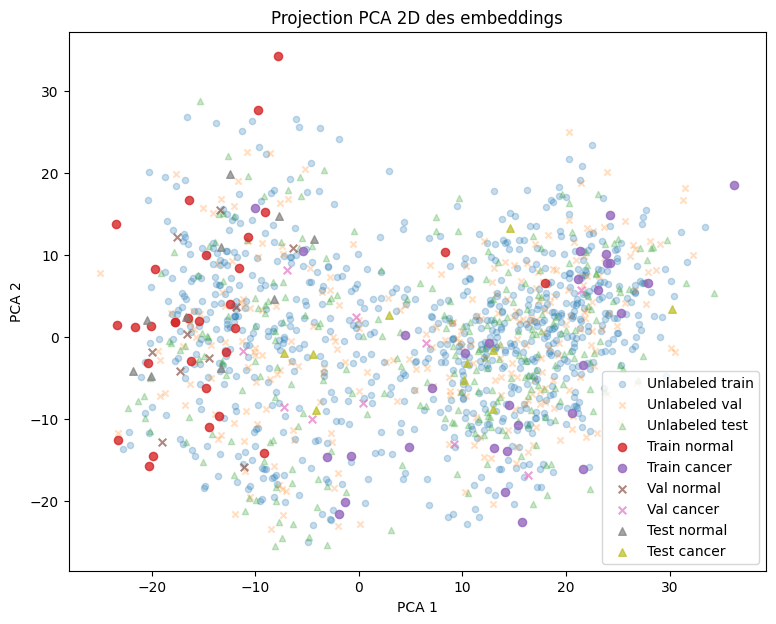

In [1464]:
plt.figure(figsize=(9, 7))

# =========================
# Images non labellisées
# =========================

plt.scatter(
    train_unla_pca_2d[:, 0],
    train_unla_pca_2d[:, 1],
    label="Unlabeled train",
    alpha=0.25,
    s=20
)

plt.scatter(
    val_unla_pca_2d[:, 0],
    val_unla_pca_2d[:, 1],
    label="Unlabeled val",
    alpha=0.25,
    s=20,
    marker="x"
)

plt.scatter(
    test_unla_pca_2d[:, 0],
    test_unla_pca_2d[:, 1],
    label="Unlabeled test",
    alpha=0.25,
    s=20,
    marker="^"
)

# =========================
# Images labellisées train
# =========================

plt.scatter(
    train_pca_2d[train_labels == 0, 0],
    train_pca_2d[train_labels == 0, 1],
    label="Train normal",
    alpha=0.8,
    s=35
)

plt.scatter(
    train_pca_2d[train_labels == 1, 0],
    train_pca_2d[train_labels == 1, 1],
    label="Train cancer",
    alpha=0.8,
    s=35
)

# =========================
# Images labellisées validation
# =========================

plt.scatter(
    val_pca_2d[val_labels == 0, 0],
    val_pca_2d[val_labels == 0, 1],
    label="Val normal",
    alpha=0.7,
    s=30,
    marker="x"
)

plt.scatter(
    val_pca_2d[val_labels == 1, 0],
    val_pca_2d[val_labels == 1, 1],
    label="Val cancer",
    alpha=0.7,
    s=30,
    marker="x"
)

# =========================
# Images labellisées test
# =========================

plt.scatter(
    test_pca_2d[test_labels == 0, 0],
    test_pca_2d[test_labels == 0, 1],
    label="Test normal",
    alpha=0.7,
    s=30,
    marker="^"
)

plt.scatter(
    test_pca_2d[test_labels == 1, 0],
    test_pca_2d[test_labels == 1, 1],
    label="Test cancer",
    alpha=0.7,
    s=30,
    marker="^"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA 2D des embeddings")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">3.3 PCA concervant 95 % de variance</h4>

In [1465]:
# ============================================================
# PCA 95 % de variance
# PCA apprise uniquement sur le train labellisé
# ============================================================

pca_95 = PCA(
    n_components=0.95,
    random_state=42
)

train_pca_95 = pca_95.fit_transform(train_scaled)

val_pca_95 = pca_95.transform(val_scaled)

test_pca_95 = pca_95.transform(test_scaled)

train_unla_pca_95 = pca_95.transform(
    train_unla_scaled
)

val_unla_pca_95 = pca_95.transform(
    val_unla_scaled
)

test_unla_pca_95 = pca_95.transform(
    test_unla_scaled
)

print(
    "Nombre de composantes conservées :",
    train_pca_95.shape[1]
)

print(
    "Variance conservée :",
    pca_95.explained_variance_ratio_.sum()
)

print("Train :", train_pca_95.shape)
print("Validation :", val_pca_95.shape)
print("Test :", test_pca_95.shape)

print("Unlabeled train :", train_unla_pca_95.shape)
print("Unlabeled val :", val_unla_pca_95.shape)
print("Unlabeled test :", test_unla_pca_95.shape)

Nombre de composantes conservées : 43
Variance conservée : 0.95014876
Train : (60, 43)
Validation : (20, 43)
Test : (20, 43)
Unlabeled train : (786, 43)
Unlabeled val : (262, 43)
Unlabeled test : (263, 43)


Comparaison des représentations

In [1466]:
from sklearn.pipeline import Pipeline

# ============================================================
# Comparaison de plusieurs espaces de représentation
# Sans fuite de données : fit uniquement sur train_features
# ============================================================

max_pca_components = min(
    train_features.shape[0],
    train_features.shape[1]
) - 1

spaces = {
    "features_scaled": None,
    "features_pca_95": PCA(
        n_components=0.95,
        random_state=42
    ),
    "features_pca_50": PCA(
        n_components=min(50, max_pca_components),
        random_state=42
    ),
    "features_pca_100": PCA(
        n_components=min(100, max_pca_components),
        random_state=42
    )
}

results = []

for representation_name, pca_step in spaces.items():

    steps = [
        ("scaler", StandardScaler())
    ]

    if pca_step is not None:
        steps.append(
            ("pca", pca_step)
        )

    steps.append(
        (
            "kmeans",
            KMeans(
                n_clusters=2,
                random_state=42,
                n_init=20
            )
        )
    )

    pipeline = Pipeline(steps)

    # Fit uniquement sur le train : scaler, PCA et KMeans
    pipeline.fit(train_features)

    for split_name, X_split, y_split in [
        ("train", train_features, train_labels),
        ("val", val_features, val_labels),
        ("test", test_features, test_labels)
    ]:

        clusters = pipeline.predict(X_split)

        X_transformed = pipeline[:-1].transform(X_split)

        ari = adjusted_rand_score(
            y_split,
            clusters
        )

        nmi = normalized_mutual_info_score(
            y_split,
            clusters
        )

        if len(np.unique(clusters)) > 1:
            sil = silhouette_score(
                X_transformed,
                clusters
            )
        else:
            sil = np.nan

        results.append({
            "representation": representation_name,
            "split": split_name,
            "ARI": ari,
            "NMI": nmi,
            "Silhouette": sil,
            "n_components": (
                X_transformed.shape[1]
                if len(X_transformed.shape) > 1
                else 1
            )
        })

df_clustering_eval = pd.DataFrame(results)

df_clustering_eval

,representation,split,ARI,NMI,Silhouette,n_components
0,features_scaled,train,0.529953,0.452404,0.109927,2048
1,features_scaled,val,0.219178,0.343711,0.122182,2048
2,features_scaled,test,0.330396,0.420791,0.083979,2048
3,features_pca_95,train,0.529953,0.452404,0.117785,43
4,features_pca_95,val,0.219178,0.343711,0.176566,43
5,features_pca_95,test,0.330396,0.420791,0.135595,43
6,features_pca_50,train,0.529953,0.452404,0.113370,50
7,features_pca_50,val,0.219178,0.343711,0.172354,50
8,features_pca_50,test,0.330396,0.420791,0.130867,50
9,features_pca_100,train,0.529953,0.452404,0.109927,59


<h4 style="color:#48C9B0;">3.4 UMAP pour visualisation non linéaire</h4>

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">
<b style="color:black;">Observation</b><br><br>

La projection UMAP permet de visualiser les embeddings dans un espace bidimensionnel en conservant davantage les relations de voisinage locales que la PCA.

Cette représentation complète l'analyse PCA en mettant en évidence d'éventuelles structures non linéaires dans les données.

Les labels connus sont uniquement utilisés pour l'interprétation visuelle de la projection et ne participent pas à la construction de l'espace UMAP.
</div>

In [1467]:
# ============================================================
# UMAP sans fuite de données
# Apprentissage uniquement sur le train labellisé
# ============================================================

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

train_umap_2d = umap_reducer.fit_transform(train_scaled)
val_umap_2d = umap_reducer.transform(val_scaled)
test_umap_2d = umap_reducer.transform(test_scaled)
train_unla_umap_2d = umap_reducer.transform(train_unla_scaled)
val_unla_umap_2d = umap_reducer.transform(val_unla_scaled)
test_unla_umap_2d = umap_reducer.transform(test_unla_scaled)

print("Train :", train_umap_2d.shape)
print("Validation :", val_umap_2d.shape)
print("Test :", test_umap_2d.shape)

print("Unlabeled train :", train_unla_umap_2d.shape)
print("Unlabeled val :", val_unla_umap_2d.shape)
print("Unlabeled test :", test_unla_umap_2d.shape)

c:\Users\gonza\Openclassroom\Projet_9\CurelyticsIA\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Train : (60, 2)
Validation : (20, 2)
Test : (20, 2)
Unlabeled train : (786, 2)
Unlabeled val : (262, 2)
Unlabeled test : (263, 2)


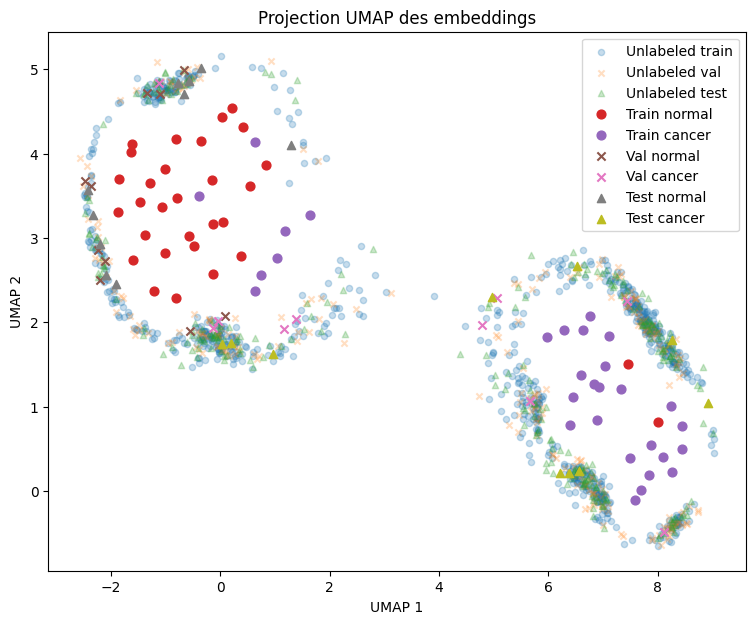

In [1468]:
plt.figure(figsize=(9, 7))

# =====================================================
# Non labellisées
# =====================================================

plt.scatter(
    train_unla_umap_2d[:, 0],
    train_unla_umap_2d[:, 1],
    label="Unlabeled train",
    alpha=0.25,
    s=20
)

plt.scatter(
    val_unla_umap_2d[:, 0],
    val_unla_umap_2d[:, 1],
    label="Unlabeled val",
    alpha=0.25,
    s=20,
    marker="x"
)

plt.scatter(
    test_unla_umap_2d[:, 0],
    test_unla_umap_2d[:, 1],
    label="Unlabeled test",
    alpha=0.25,
    s=20,
    marker="^"
)

# =====================================================
# Train labellisé
# =====================================================

plt.scatter(
    train_umap_2d[train_labels == 0, 0],
    train_umap_2d[train_labels == 0, 1],
    label="Train normal",
    s=40
)

plt.scatter(
    train_umap_2d[train_labels == 1, 0],
    train_umap_2d[train_labels == 1, 1],
    label="Train cancer",
    s=40
)

# =====================================================
# Validation labellisée
# =====================================================

plt.scatter(
    val_umap_2d[val_labels == 0, 0],
    val_umap_2d[val_labels == 0, 1],
    label="Val normal",
    marker="x",
    s=35
)

plt.scatter(
    val_umap_2d[val_labels == 1, 0],
    val_umap_2d[val_labels == 1, 1],
    label="Val cancer",
    marker="x",
    s=35
)

# =====================================================
# Test labellisé
# =====================================================

plt.scatter(
    test_umap_2d[test_labels == 0, 0],
    test_umap_2d[test_labels == 0, 1],
    label="Test normal",
    marker="^",
    s=35
)

plt.scatter(
    test_umap_2d[test_labels == 1, 0],
    test_umap_2d[test_labels == 1, 1],
    label="Test cancer",
    marker="^",
    s=35
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP des embeddings")
plt.legend()
plt.show()

AgglomerativeClustering

Le clustering hiérarchique ne possède pas de méthode `predict`, contrairement à KMeans.  
Il est donc évalué séparément sur chaque split afin d'éviter de regrouper train, validation et test dans une même construction de clusters.

Cette analyse permet de comparer la capacité de chaque méthode de linkage à retrouver une structure cohérente au sein de chaque jeu de données, sans mélanger les données entre elles.

In [1469]:
# ============================================================
# Clustering hiérarchique sans fuite de données
# Évaluation séparée sur train, validation et test
# ============================================================

hierarchical_results = []

for linkage in ["ward", "complete", "average"]:

    for split_name, X_split, y_split in [
        ("train", train_pca_95, train_labels),
        ("val", val_pca_95, val_labels),
        ("test", test_pca_95, test_labels)
    ]:

        clustering = AgglomerativeClustering(
            n_clusters=2,
            linkage=linkage
        )

        clusters = clustering.fit_predict(X_split)

        ari = adjusted_rand_score(
            y_split,
            clusters
        )

        nmi = normalized_mutual_info_score(
            y_split,
            clusters
        )

        hierarchical_results.append({
            "linkage": linkage,
            "split": split_name,
            "ARI": ari,
            "NMI": nmi
        })

df_hierarchical_results = pd.DataFrame(hierarchical_results)

df_hierarchical_results

,linkage,split,ARI,NMI
0,ward,train,0.481455,0.415483
1,ward,val,0.330396,0.420791
2,ward,test,0.620843,0.618977
3,complete,train,0.006802,0.080689
4,complete,val,0.130719,0.274637
5,complete,test,0.219178,0.343711
6,average,train,0.000000,0.030064
7,average,val,0.000000,0.080689
8,average,test,0.620843,0.618977


<h2 style="color:#48C9B0;">4 Clustering non supervisé</h2>

<h4 style="color:#48C9B0;">4.1 K-Means</h4>

In [1470]:
# ============================================================
# Choix du nombre de clusters
# Sans fuite de données
# ============================================================

k_values = range(2, 9)

results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(
        train_pca_95
    )

    score = silhouette_score(
        train_pca_95,
        clusters
    )

    results.append({
        "k": k,
        "silhouette_score": score
    })

df_kmeans_results = pd.DataFrame(results)

df_kmeans_results

,k,silhouette_score
0,2,0.117785
1,3,0.107473
2,4,0.094264
3,5,0.118312
4,6,0.103398
5,7,0.092194
6,8,0.094647


Les embeddings présentent une organisation interne détectable par KMeans. Cependant, les scores silhouette restent faibles, ce qui suggère que les groupes naturels présents dans l'espace des embeddings ne sont pas fortement séparés.

Graphique du score silhouette

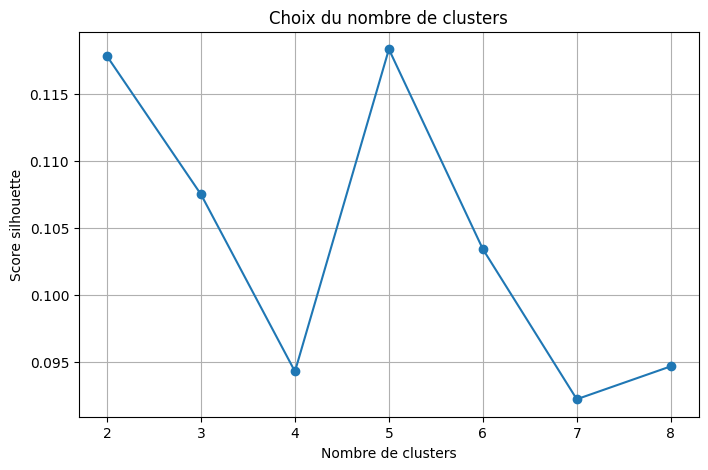

In [1471]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_kmeans_results["k"],
    df_kmeans_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Nombre de clusters")
plt.ylabel("Score silhouette")
plt.title("Choix du nombre de clusters")
plt.grid()

plt.show()

<h4 style="color:#48C9B0;">4.2 Choix du nombre de clusters</h4>

In [1472]:
k_optimal = 2

Le choix de k=2 est guidé par le problème métier, qui oppose deux classes connues : Normal et Cancer. 
La silhouette est utilisée comme indicateur complémentaire, mais ne constitue pas l’unique critère de décision.

<h4 style="color:#48C9B0;">4.3 DBSCAN</h4>

L'analyse DBSCAN est réalisée uniquement sur le jeu d'entraînement afin d'éviter toute fuite de données.

Contrairement à KMeans, DBSCAN ne permet pas de prédire l'appartenance de nouvelles observations à des clusters déjà appris. Cette méthode est donc utilisée uniquement à des fins exploratoires pour détecter d'éventuelles zones de forte densité dans l'espace des embeddings.

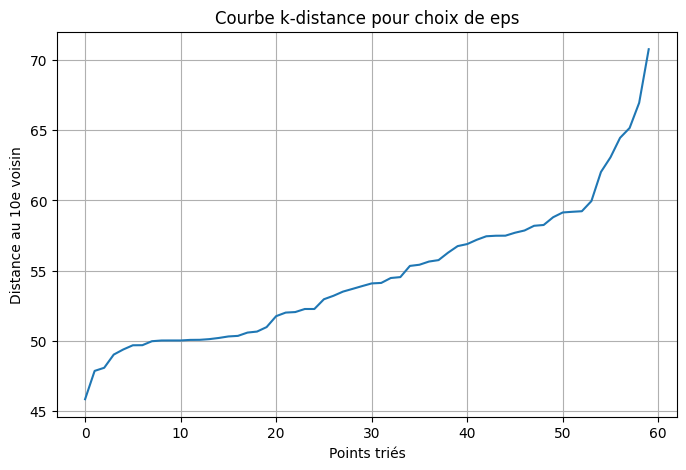

In [1473]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(train_pca_95)
distances, indices = neighbors_fit.kneighbors(train_pca_95)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("Courbe k-distance pour choix de eps")
plt.xlabel("Points triés")
plt.ylabel("Distance au 10e voisin")
plt.grid()
plt.show()

In [1474]:
# ============================================================
# DBSCAN sur le jeu d'entraînement uniquement
# ============================================================

dbscan = DBSCAN(
    eps=3,
    min_samples=10
)

clusters_dbscan = dbscan.fit_predict(
    train_pca_95
)

print(
    pd.Series(clusters_dbscan)
    .value_counts()
    .sort_index()
)

-1    60
Name: count, dtype: int64


In [1475]:
n_clusters = len(
    set(clusters_dbscan)
) - (
    1 if -1 in clusters_dbscan else 0
)

n_noise = (
    clusters_dbscan == -1
).sum()

print("Clusters trouvés :", n_clusters)
print("Points de bruit :", n_noise)
print(
    "Pourcentage de bruit :",
    round(
        100 * n_noise / len(clusters_dbscan),
        1
    ),
    "%"
)

Clusters trouvés : 0
Points de bruit : 60
Pourcentage de bruit : 100.0 %


In [1476]:
for eps in [5, 10, 15, 20, 25]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    clusters = dbscan.fit_predict(
        train_pca_95
    )

    n_clusters = len(
        set(clusters)
    ) - (
        1 if -1 in clusters else 0
    )

    n_noise = (
        clusters == -1
    ).sum()

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"bruit={n_noise}"
    )

eps=5 | clusters=0 | bruit=60
eps=10 | clusters=0 | bruit=60
eps=15 | clusters=0 | bruit=60
eps=20 | clusters=0 | bruit=60
eps=25 | clusters=0 | bruit=60


<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">
<b style="color:black;">Observation</b><br><br>

Plusieurs valeurs du paramètre <i>eps</i> ont été testées afin d'identifier d'éventuels groupes denses dans l'espace des embeddings. Quelle que soit la configuration retenue, DBSCAN n'a détecté aucun cluster et a classé l'ensemble des observations comme du bruit.

Ce résultat suggère que les embeddings extraits par ResNet50 ne forment pas de régions fortement denses et bien séparées. Les observations semblent plutôt organisées selon des structures diffuses et partiellement chevauchantes.

Cette conclusion est cohérente avec le faible score silhouette obtenu précédemment. Dans ce contexte, une approche basée sur des centroïdes comme KMeans apparaît plus adaptée que DBSCAN pour explorer l'organisation des données.
</div>

<h4 style="color:#48C9B0;">4.4 Comparaison des méthodes</h4>

In [1477]:
# ============================================================
# KMeans final
# Entraînement uniquement sur le train labellisé
# ============================================================

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans_final.fit(train_pca_95)

# -----------------------
# Données labellisées
# -----------------------

train_clusters = kmeans_final.predict(
    train_pca_95
)

val_clusters = kmeans_final.predict(
    val_pca_95
)

test_clusters = kmeans_final.predict(
    test_pca_95
)

# -----------------------
# Données non labellisées
# -----------------------

train_unla_clusters = kmeans_final.predict(
    train_unla_pca_95
)

val_unla_clusters = kmeans_final.predict(
    val_unla_pca_95
)

test_unla_clusters = kmeans_final.predict(
    test_unla_pca_95
)

In [1478]:
# ============================================================
# Résultats labellisés
# ============================================================

df_train_results = pd.DataFrame({
    "split": "train",
    "label_reel": train_labels,
    "cluster": train_clusters,
    "pca_1": train_pca_2d[:, 0],
    "pca_2": train_pca_2d[:, 1]
})

df_val_results = pd.DataFrame({
    "split": "val",
    "label_reel": val_labels,
    "cluster": val_clusters,
    "pca_1": val_pca_2d[:, 0],
    "pca_2": val_pca_2d[:, 1]
})

df_test_results = pd.DataFrame({
    "split": "test",
    "label_reel": test_labels,
    "cluster": test_clusters,
    "pca_1": test_pca_2d[:, 0],
    "pca_2": test_pca_2d[:, 1]
})

df_labeled_results = pd.concat(
    [
        df_train_results,
        df_val_results,
        df_test_results
    ],
    ignore_index=True
)

df_labeled_results.head()

,split,label_reel,cluster,pca_1,pca_2
0,train,0,0,-17.789473,1.799498
1,train,1,1,14.537077,-8.244494
2,train,0,1,8.280997,10.439722
3,train,0,0,-14.784820,10.050399
4,train,0,0,-19.691730,8.303686


In [1479]:
# ============================================================
# Résultats non labellisés
# ============================================================

df_train_unla_results = pd.DataFrame({
    "split": "train_unla",
    "cluster": train_unla_clusters,
    "pca_1": train_unla_pca_2d[:, 0],
    "pca_2": train_unla_pca_2d[:, 1]
})

df_val_unla_results = pd.DataFrame({
    "split": "val_unla",
    "cluster": val_unla_clusters,
    "pca_1": val_unla_pca_2d[:, 0],
    "pca_2": val_unla_pca_2d[:, 1]
})

df_test_unla_results = pd.DataFrame({
    "split": "test_unla",
    "cluster": test_unla_clusters,
    "pca_1": test_unla_pca_2d[:, 0],
    "pca_2": test_unla_pca_2d[:, 1]
})

df_unlabeled_results = pd.concat(
    [
        df_train_unla_results,
        df_val_unla_results,
        df_test_unla_results
    ],
    ignore_index=True
)

df_unlabeled_results.head()

,split,cluster,pca_1,pca_2
0,train_unla,0,-3.488925,6.195405
1,train_unla,1,18.578985,16.786194
2,train_unla,1,16.343006,1.256763
3,train_unla,0,-13.493054,6.304024
4,train_unla,0,-4.258124,-12.645335


<h2 style="color:#48C9B0;">5 Analyse des clusters avec les labels connus</h2>

<h4 style="color:#48C9B0;">5.1 Répartition cancer / normal par cluster</h4>

In [1480]:
# ============================================================
# Composition des clusters sur le train uniquement
# ============================================================

cluster_label_table_train = pd.crosstab(
    df_train_results["cluster"],
    df_train_results["label_reel"],
    normalize="index"
)

cluster_label_table_train.columns = ["normal", "cancer"]


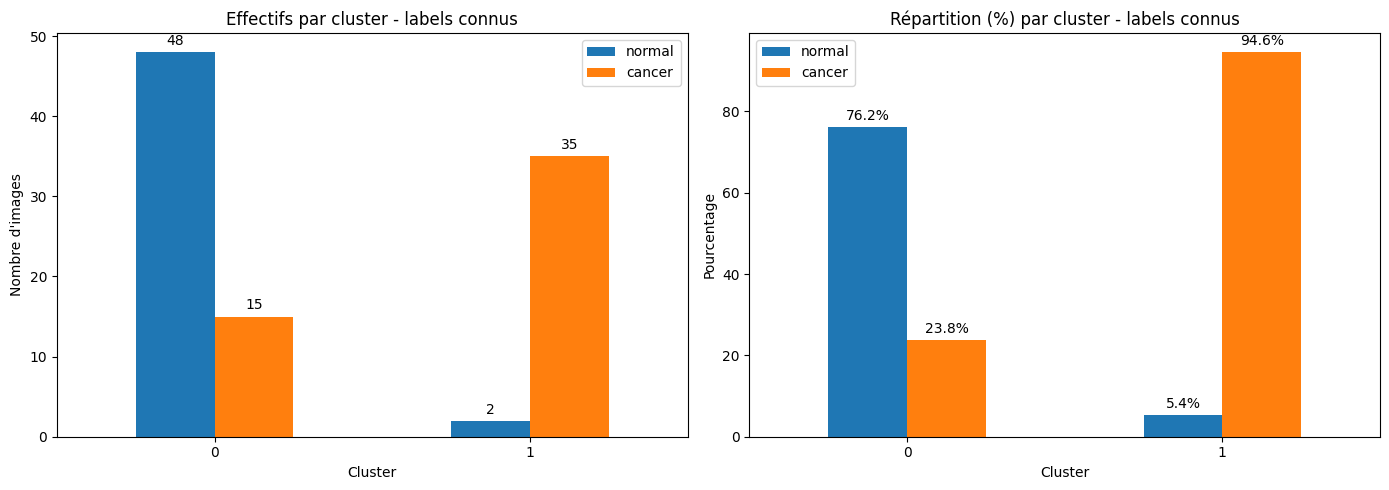

In [1481]:
cluster_counts = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"]
)

cluster_counts.columns = ["normal", "cancer"]

cluster_percentages = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"],
    normalize="index"
) * 100

cluster_percentages.columns = ["normal", "cancer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------
# Effectifs
# ----------------------

cluster_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Effectifs par cluster - labels connus")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%d",
        padding=3
    )

# ----------------------
# Pourcentages
# ----------------------

cluster_percentages.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Répartition (%) par cluster - labels connus")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Pourcentage")
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">5.2 Interpretation des clusters</h4>

Les clusters sont interprétés uniquement à partir du jeu d'entraînement afin d'éviter toute fuite d'information depuis les jeux de validation et de test.

Un cluster est associé au profil "Normal" ou "cancer" selon la classe majoritaire observée dans le train. Cette association reste exploratoire : elle ne signifie pas que le clustering réalise un diagnostic médical, mais uniquement qu'il regroupe des images visuellement proches des exemples connus.

<h4 style="color:#48C9B0;">5.3 Evaluation des clusters (ARI, NMI)</h4>

L'évaluation du clustering est réalisée dans un cadre sans fuite de données.

La standardisation, la réduction de dimension par PCA et l'apprentissage des centroïdes KMeans sont effectués uniquement sur le jeu d'entraînement.

Les jeux de validation et de test sont ensuite projetés dans l'espace appris sur le train puis affectés aux clusters correspondants.

Les métriques ARI, NMI et Silhouette permettent d'évaluer la cohérence des regroupements obtenus sur chacun des jeux de données.

In [1482]:
results = []

for split_name, X, y in [
    ("Train", train_pca_95, train_labels),
    ("Validation", val_pca_95, val_labels),
    ("Test", test_pca_95, test_labels)
]:

    clusters = kmeans_final.predict(X)

    ari = adjusted_rand_score(y, clusters)
    nmi = normalized_mutual_info_score(y, clusters)

    sil = silhouette_score(X, clusters) if len(np.unique(clusters)) > 1 else np.nan

    results.append({
        "Split": split_name,
        "ARI": ari,
        "NMI": nmi,
        "Silhouette": sil
    })

df_clustering_metrics = pd.DataFrame(results)
df_clustering_metrics

,Split,ARI,NMI,Silhouette
0,Train,0.529953,0.452404,0.117785
1,Validation,0.219178,0.343711,0.176566
2,Test,0.330396,0.420791,0.135595


<h2 style="color:#48C9B0;">6 Pseudo-labellisation exploratoire</h2>

<h4 style="color:#48C9B0;">6.1 Attribution d'un profil probable</h4>

In [1483]:
# ============================================================
# Répartition des images non labellisées par cluster
# ============================================================
cluster_distribution = (
    df_unlabeled_results["cluster"]
    .value_counts()
    .sort_index()
)

cluster_distribution


cluster
0    525
1    786
Name: count, dtype: int64

In [1484]:
cluster_mapping = {}

for cluster in cluster_label_table_train.index:

    if cluster_label_table_train.loc[cluster, "cancer"] > cluster_label_table_train.loc[cluster, "normal"]:
        cluster_mapping[cluster] = "cancer"
    else:
        cluster_mapping[cluster] = "normal"

print(cluster_mapping)

{0: 'normal', 1: 'cancer'}


In [1485]:
df_unlabeled_results["profil_probable"] = (
    df_unlabeled_results["cluster"]
    .map(cluster_mapping)
)

df_unlabeled_results.head()

,split,cluster,pca_1,pca_2,profil_probable
0,train_unla,0,-3.488925,6.195405,normal
1,train_unla,1,18.578985,16.786194,cancer
2,train_unla,1,16.343006,1.256763,cancer
3,train_unla,0,-13.493054,6.304024,normal
4,train_unla,0,-4.258124,-12.645335,normal


Les images non labellisées ont été projetées dans le même espace de représentation que les images de référence. Chaque observation est ensuite associée au cluster le plus proche, ce qui permet d'attribuer un profil probable. Dans cet extrait, certaines images sont rattachées au cluster majoritairement cancéreux tandis que d'autres rejoignent le cluster majoritairement normal. Cette approche permet d'exploiter les structures identifiées par le clustering pour proposer une première catégorisation des données non annotées.

<h4 style="color:#48C9B0;">6.2 Analyse des images non labellisées</h4>

In [1486]:
cluster_distribution = (
    df_unlabeled_results["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_distribution

cluster
0    40.045767
1    59.954233
Name: proportion, dtype: float64

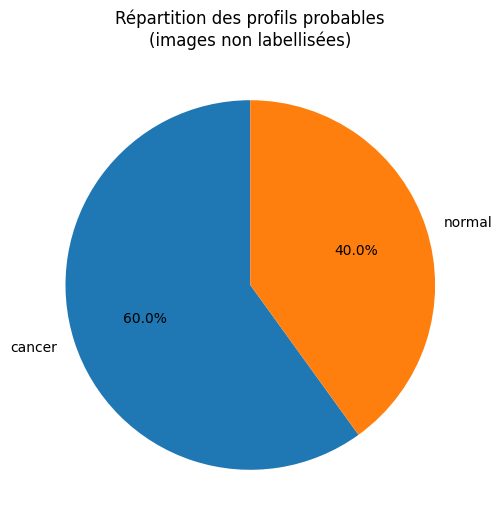

In [1487]:
cluster_distribution = (
    df_unlabeled_results["profil_probable"]
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    cluster_distribution,
    labels=cluster_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Répartition des profils probables\n(images non labellisées)"
)

plt.show()

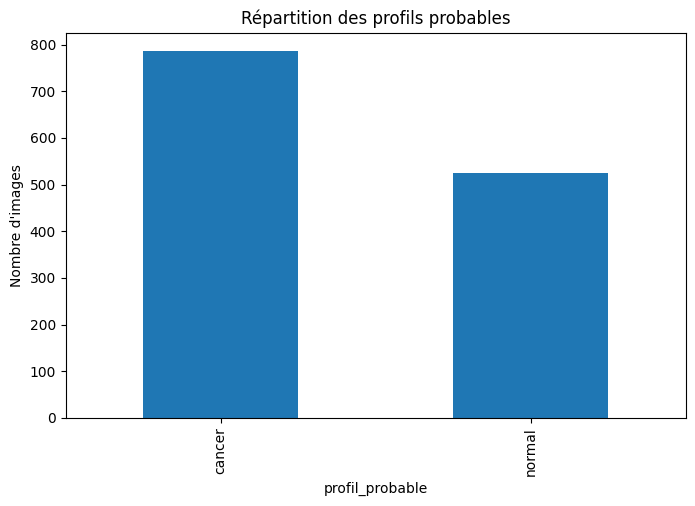

In [1488]:
plt.figure(figsize=(8,5))

df_unlabeled_results[
    "profil_probable"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Répartition des profils probables"
)

plt.ylabel("Nombre d'images")
plt.show()

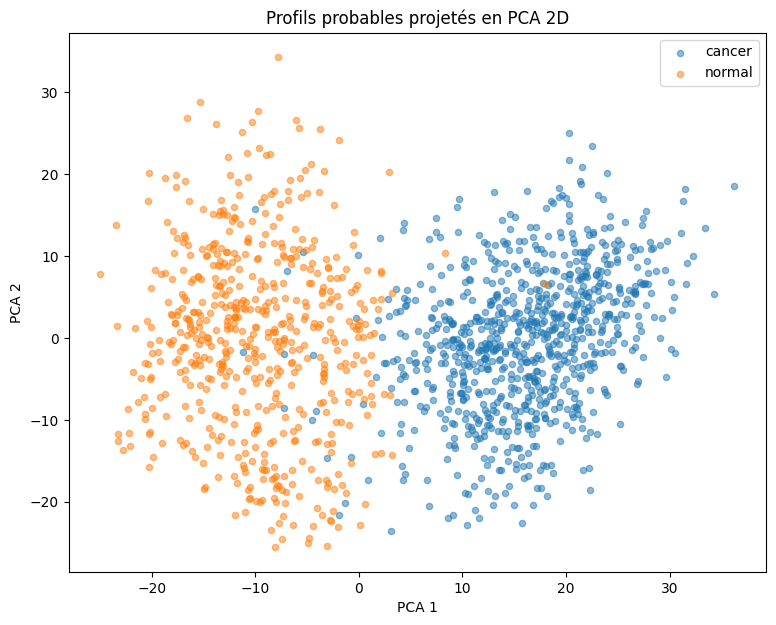

In [1489]:
df_labeled_results["profil_probable"] = df_labeled_results["label_reel"].map({
    0: "normal",
    1: "cancer"
})

df_results = pd.concat(
    [
        df_labeled_results,
        df_unlabeled_results
    ],
    ignore_index=True
)

plt.figure(figsize=(9, 7))

for profil in sorted(df_results["profil_probable"].dropna().unique()):

    mask = df_results["profil_probable"] == profil

    plt.scatter(
        df_results.loc[mask, "pca_1"],
        df_results.loc[mask, "pca_2"],
        label=profil,
        alpha=0.5,
        s=20
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Profils probables projetés en PCA 2D")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">6.3 Score de confiance</h4>

In [1490]:
# ============================================================
# Calcul de la distance au centroïde pour les images non labellisées
# ============================================================
# ============================================================
# PCA des non labellisées
# ============================================================

unlabeled_pca_95 = np.concatenate(
    [
        train_unla_pca_95,
        val_unla_pca_95,
        test_unla_pca_95
    ],
    axis=0
)

distances_to_centers_unlabeled = kmeans_final.transform(
    unlabeled_pca_95
)

df_unlabeled_results["distance_centroid"] = distances_to_centers_unlabeled[
    np.arange(len(df_unlabeled_results)),
    df_unlabeled_results["cluster"].values
]

df_unlabeled_results[
    [
        "cluster",
        "distance_centroid"
    ]
].head()

,cluster,distance_centroid
0,0,52.101387
1,1,36.971931
2,1,34.370052
3,0,26.916246
4,0,26.766886


In [1491]:
# ============================================================
# Confiance basée sur la distance au centroïde
# Plus la distance est faible, plus la confiance est élevée
# ============================================================

df_unlabeled_results["distance_centroid_norm"] = (
    df_unlabeled_results
    .groupby("cluster")["distance_centroid"]
    .transform(
        lambda x: (
            (x - x.min()) / (x.max() - x.min())
            if x.max() != x.min()
            else np.zeros(len(x))
        )
    )
)

df_unlabeled_results["confiance_distance"] = (
    1 - df_unlabeled_results["distance_centroid_norm"]
)


In [1492]:
df_unlabeled_results[
    [
        "cluster",
        "distance_centroid",
        "confiance_distance"
    ]
].head()

,cluster,distance_centroid,confiance_distance
0,0,52.101387,0.062169
1,1,36.971931,0.456885
2,1,34.370052,0.531256
3,0,26.916246,0.785653
4,0,26.766886,0.789943


<!-- Images les plus confiantes -->

In [1493]:
df_unlabeled_results.sort_values(
    "confiance_distance",
    ascending=False
).head()

,split,cluster,pca_1,pca_2,profil_probable,distance_centroid,distance_centroid_norm,confiance_distance
1204,test_unla,0,-8.096489,0.692011,normal,19.454626,0.000000,1.000000
1156,test_unla,1,22.076189,3.746125,cancer,17.970997,0.000000,1.000000
1256,test_unla,1,17.093445,0.335428,cancer,19.317907,0.038500,0.961500
533,train_unla,0,-8.166903,1.097569,normal,20.810461,0.038949,0.961051
367,train_unla,0,-15.337927,-3.231710,normal,20.971903,0.043586,0.956414


In [1494]:
df_unlabeled_results.sort_values(
    "confiance_distance",
    ascending=True
).head()

,split,cluster,pca_1,pca_2,profil_probable,distance_centroid,distance_centroid_norm,confiance_distance
1242,test_unla,1,4.040820,-3.543941,cancer,52.956097,1.000000,0.000000
286,train_unla,0,-9.881362,9.664448,normal,54.265541,1.000000,0.000000
0,train_unla,0,-3.488925,6.195405,normal,52.101387,0.937831,0.062169
1105,test_unla,1,7.417940,14.642233,cancer,50.479179,0.929201,0.070799
872,val_unla,0,-4.704536,8.418677,normal,51.479347,0.919962,0.080038


In [1495]:
cluster_confidence = {}

for cluster in cluster_label_table_train.index:
    cluster_confidence[cluster] = cluster_label_table_train.loc[cluster].max()

print(cluster_confidence)

{0: np.float64(0.8235294117647058), 1: np.float64(0.9230769230769231)}


In [1496]:
df_unlabeled_results["confiance_cluster"] = (
    df_unlabeled_results["cluster"]
    .map(cluster_confidence)
)

df_unlabeled_results["confiance_finale"] = (
    df_unlabeled_results["confiance_cluster"]
    *
    df_unlabeled_results["confiance_distance"]
)

In [1497]:
df_unlabeled_results.sort_values(
    "confiance_finale",
    ascending=False
).head()

,split,cluster,pca_1,pca_2,profil_probable,distance_centroid,distance_centroid_norm,confiance_distance,confiance_cluster,confiance_finale
1156,test_unla,1,22.076189,3.746125,cancer,17.970997,0.000000,1.000000,0.923077,0.923077
1256,test_unla,1,17.093445,0.335428,cancer,19.317907,0.038500,0.961500,0.923077,0.887539
540,train_unla,1,18.875412,1.047904,cancer,19.697714,0.049356,0.950644,0.923077,0.877518
180,train_unla,1,13.255195,-1.185475,cancer,19.789925,0.051991,0.948008,0.923077,0.875085
897,val_unla,1,16.399504,1.661163,cancer,20.089148,0.060544,0.939456,0.923077,0.867190


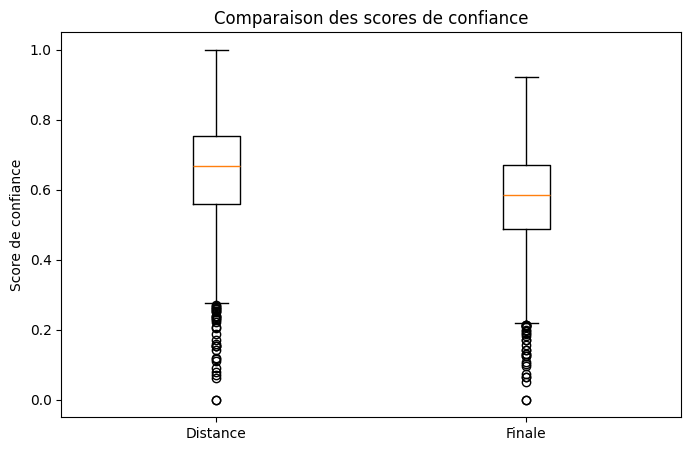

In [1498]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df_unlabeled_results["confiance_distance"],
        df_unlabeled_results["confiance_finale"]
    ],
    tick_labels=[
        "Distance",
        "Finale"
    ]
)

plt.title("Comparaison des scores de confiance")
plt.ylabel("Score de confiance")

plt.show()

Sauvegarde

In [1499]:
print(df_unlabeled_results["profil_probable"].value_counts(dropna=False))
print(df_unlabeled_results["confiance_finale"].describe())

profil_probable
cancer    786
normal    525
Name: count, dtype: int64
count    1311.000000
mean        0.568818
std         0.141572
min         0.000000
25%         0.488585
50%         0.586334
75%         0.669577
max         0.923077
Name: confiance_finale, dtype: float64


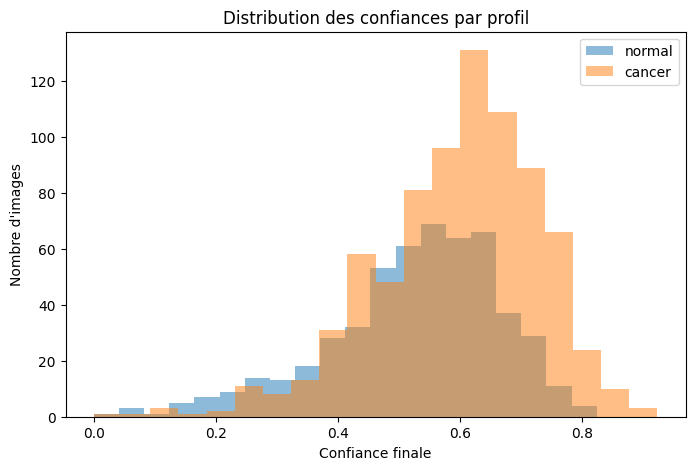

In [1500]:
plt.figure(figsize=(8,5))

for profil in ["normal", "cancer"]:

    plt.hist(
        df_unlabeled_results.loc[
            df_unlabeled_results["profil_probable"] == profil,
            "confiance_finale"
        ],
        bins=20,
        alpha=0.5,
        label=profil
    )

plt.title("Distribution des confiances par profil")
plt.xlabel("Confiance finale")
plt.ylabel("Nombre d'images")
plt.legend()

plt.show()

In [1501]:
seuils = np.arange(0, 1.01, 0.05)

resultats = []

for seuil in seuils:

    tmp = df_unlabeled_results[
        df_unlabeled_results["confiance_finale"] >= seuil
    ]

    resultats.append({
        "seuil": seuil,
        "nb_images": len(tmp),
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum()
    })

df_seuils = pd.DataFrame(resultats)

print(df_seuils)

    seuil  nb_images  cancer  normal
0    0.00       1311     786     525
1    0.05       1309     785     524
2    0.10       1304     784     520
3    0.15       1296     780     516
4    0.20       1288     780     508
5    0.25       1274     776     498
6    0.30       1243     763     480
7    0.35       1214     749     465
8    0.40       1160     725     435
9    0.45       1066     670     396
10   0.50        952     619     333
11   0.55        797     535     262
12   0.60        604     432     172
13   0.65        392     299      93
14   0.70        210     166      44
15   0.75         98      86      12
16   0.80         22      21       1
17   0.85          7       7       0
18   0.90          1       1       0
19   0.95          0       0       0
20   1.00          0       0       0


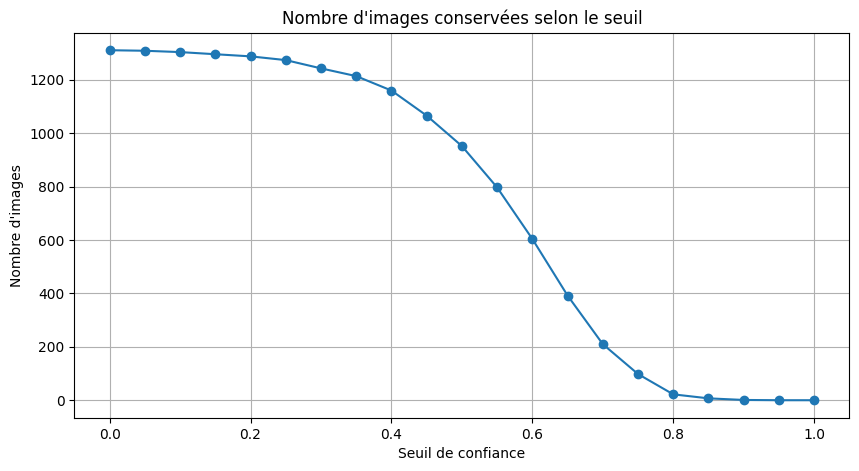

In [1502]:
plt.figure(figsize=(10,5))

plt.plot(
    df_seuils["seuil"],
    df_seuils["nb_images"],
    marker="o"
)

plt.title("Nombre d'images conservées selon le seuil")
plt.xlabel("Seuil de confiance")
plt.ylabel("Nombre d'images")

plt.grid(True)

plt.show()

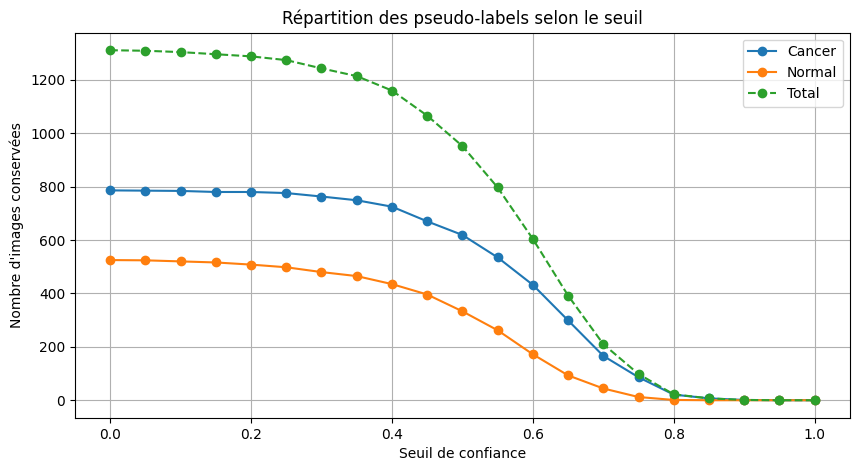

In [1503]:
seuils = np.arange(0, 1.01, 0.05)

stats = []

for seuil in seuils:

    tmp = df_unlabeled_results[
        df_unlabeled_results["confiance_finale"] >= seuil
    ]

    stats.append({
        "seuil": seuil,
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum(),
        "total": len(tmp)
    })

stats = pd.DataFrame(stats)

plt.figure(figsize=(10,5))

plt.plot(
    stats["seuil"],
    stats["cancer"],
    label="Cancer",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["normal"],
    label="Normal",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["total"],
    label="Total",
    marker="o",
    linestyle="--"
)

plt.title("Répartition des pseudo-labels selon le seuil")
plt.xlabel("Seuil de confiance")
plt.ylabel("Nombre d'images conservées")

plt.legend()
plt.grid(True)

plt.show()

<h4 style="color:#48C9B0;">6.4 Limites de l'approche</h4>

La pseudo-labellisation reste exploratoire. Les clusters sont associés aux classes "normal" et "cancer" à partir de la classe majoritaire observée dans le train, mais cette association ne constitue pas une validation médicale.

Les pseudo-labels peuvent contenir des erreurs, surtout pour les images éloignées des centroïdes ou appartenant à des zones de chevauchement.

Les scores de confiance sont des scores internes au modèle. Ils ne remplacent ni une annotation experte, ni une validation clinique.

L'utilisation des pseudo-labels pour entraîner un modèle semi-supervisé doit donc être interprétée comme une stratégie d'enrichissement faible, et non comme une vérité terrain.

<h2 style="color:#48C9B0;">7. Entraînement supervisé et semi-supervisé</h2>

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">
<b style="color:black;">Objectif</b><br><br>

Dans cette partie, je compare deux stratégies d'entraînement :

<ul>
<li>une approche supervisée, entraînée uniquement sur les images fortement labellisées ;</li>
<li>une approche semi-supervisée, pré-entraînée sur des images faiblement labellisées puis affinée sur les images fortement labellisées.</li>
</ul>

Pour éviter les fuites de données, les jeux train, validation et test sont séparés strictement.  
Le jeu de test contient uniquement des images réellement labellisées et n'est jamais utilisé pendant l'entraînement.
</div>

7.1 Préparation des jeux de données

In [1504]:
# ============================================================
# 7.1 Préparation des jeux de données
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
BATCH_SIZE = 8
NUM_EPOCHS_SUPERVISED = 8
NUM_EPOCHS_WEAK = 5
NUM_EPOCHS_FINETUNE = 10

LEARNING_RATE = 1e-5

DATASET_CLEAN = Path("../data/images_clean")

print("Device utilisé :", device)

Device utilisé : cpu


Transformations adaptées à ResNet18

In [1505]:
# Transformations adaptées à ResNet

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

7.2 Dataset PyTorch

In [1506]:
# Dataset PyTorch

class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "chemin"]
        label = int(self.dataframe.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

8.5 Préparation stricte des données fortement labellisées

In [1507]:
strong_train_df = train_metadata.copy()
strong_val_df = val_metadata.copy()
strong_test_df = test_metadata.copy()

label_mapping = {
    "normal": 0,
    "cancer": 1,
    "Normal": 0,
    "Cancer": 1
}

strong_train_df["label"] = strong_train_df["classe"].map(label_mapping)
strong_val_df["label"] = strong_val_df["classe"].map(label_mapping)
strong_test_df["label"] = strong_test_df["classe"].map(label_mapping)

print("Train fort :", strong_train_df["classe"].value_counts().to_dict())
print("Validation forte :", strong_val_df["classe"].value_counts().to_dict())
print("Test fort :", strong_test_df["classe"].value_counts().to_dict())

assert strong_train_df["label"].isin([0, 1]).all()
assert strong_val_df["label"].isin([0, 1]).all()
assert strong_test_df["label"].isin([0, 1]).all()

Train fort : {'cancer': 30, 'normal': 30}
Validation forte : {'cancer': 10, 'normal': 10}
Test fort : {'normal': 10, 'cancer': 10}


In [1508]:
# DataLoaders fortement labellisés
strong_train_dataset = BrainDataset(strong_train_df, transform=train_transform)
strong_val_dataset = BrainDataset(strong_val_df, transform=eval_transform)
strong_test_dataset = BrainDataset(strong_test_df, transform=eval_transform)

strong_train_loader = DataLoader(strong_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
strong_val_loader = DataLoader(strong_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
strong_test_loader = DataLoader(strong_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

8.6 Préparation des données faiblement labellisées

In [1509]:
# ============================================================
# Création de la colonne profil_probable si elle n'existe pas
# ============================================================

df_train_unla_results["profil_probable"] = (
    df_train_unla_results["cluster"]
    .map(cluster_mapping)
)

df_val_unla_results["profil_probable"] = (
    df_val_unla_results["cluster"]
    .map(cluster_mapping)
)

df_test_unla_results["profil_probable"] = (
    df_test_unla_results["cluster"]
    .map(cluster_mapping)
)

In [1510]:
# ============================================================
# Préparation des datasets faiblement labellisés
# ============================================================

weak_train_df = train_unla_metadata.copy()
weak_val_df = val_unla_metadata.copy()
weak_test_df = test_unla_metadata.copy()

weak_train_df["profil_probable"] = df_train_unla_results["profil_probable"].values
weak_val_df["profil_probable"] = df_val_unla_results["profil_probable"].values
weak_test_df["profil_probable"] = df_test_unla_results["profil_probable"].values

pseudo_label_mapping = {
    "normal": 0,
    "cancer": 1
}

weak_train_df["label"] = weak_train_df["profil_probable"].map(pseudo_label_mapping)
weak_val_df["label"] = weak_val_df["profil_probable"].map(pseudo_label_mapping)
weak_test_df["label"] = weak_test_df["profil_probable"].map(pseudo_label_mapping)

print("Train faible :", weak_train_df["profil_probable"].value_counts().to_dict())
print("Validation faible :", weak_val_df["profil_probable"].value_counts().to_dict())
print("Test faible :", weak_test_df["profil_probable"].value_counts().to_dict())

assert weak_train_df["label"].isin([0, 1]).all()
assert weak_val_df["label"].isin([0, 1]).all()
assert weak_test_df["label"].isin([0, 1]).all()

Train faible : {'cancer': 466, 'normal': 320}
Validation faible : {'cancer': 161, 'normal': 101}
Test faible : {'cancer': 159, 'normal': 104}


Filtrage des pseudo-labels peu fiables

In [1511]:
df_train_unla_results_conf = df_train_unla_results.merge(
    df_unlabeled_results[["split", "cluster", "pca_1", "pca_2", "confiance_finale"]],
    on=["split", "cluster", "pca_1", "pca_2"],
    how="left"
)

weak_train_df_original = df_train_unla_results_conf.copy()


In [1512]:
# ============================================================
# Sélection équilibrée de pseudo-labels
# Version moins stricte : objectif 300 images faibles
# 150 normal / 150 cancer
# ============================================================

SEUIL_NORMAL = 0.55
SEUIL_CANCER = 0.60

N_PAR_CLASSE_MAX = 300

weak_train_df = weak_train_df.copy()

weak_train_df["confiance_finale"] = (
    df_train_unla_results_conf["confiance_finale"].values
)

weak_train_df["confiance_cluster"] = (
    df_train_unla_results_conf["cluster"]
    .map(cluster_confidence)
    .values
)

weak_train_df["profil_probable"] = (
    weak_train_df["profil_probable"]
    .astype(str)
    .str.lower()
)

weak_train_df["label"] = (
    weak_train_df["profil_probable"]
    .map({
        "normal": 0,
        "cancer": 1
    })
)

weak_normal_df = weak_train_df[
    (weak_train_df["profil_probable"] == "normal")
    &
    (weak_train_df["confiance_finale"] >= SEUIL_NORMAL)
].copy()

weak_cancer_df = weak_train_df[
    (weak_train_df["profil_probable"] == "cancer")
    &
    (weak_train_df["confiance_finale"] >= SEUIL_CANCER)
].copy()

print("Normal après seuil :", len(weak_normal_df))
print("Cancer après seuil :", len(weak_cancer_df))

n_par_classe = min(
    len(weak_normal_df),
    len(weak_cancer_df),
    N_PAR_CLASSE_MAX
)

weak_normal_df = (
    weak_normal_df
    .sort_values("confiance_finale", ascending=False)
    .head(n_par_classe)
)

weak_cancer_df = (
    weak_cancer_df
    .sort_values("confiance_finale", ascending=False)
    .head(n_par_classe)
)

weak_train_df = pd.concat(
    [weak_normal_df, weak_cancer_df],
    ignore_index=True
)

weak_train_df = (
    weak_train_df
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("\nNombre total retenu :", len(weak_train_df))

print("\nRépartition profil probable :")
print(weak_train_df["profil_probable"].value_counts())

print("\nRépartition labels numériques :")
print(weak_train_df["label"].value_counts().sort_index())

print("\nConfiance finale :")
print(
    weak_train_df.groupby("profil_probable")[
        "confiance_finale"
    ].describe()
)

Normal après seuil : 168
Cancer après seuil : 252

Nombre total retenu : 336

Répartition profil probable :
profil_probable
normal    168
cancer    168
Name: count, dtype: int64

Répartition labels numériques :
label
0    168
1    168
Name: count, dtype: int64

Confiance finale :
                 count      mean       std       min       25%       50%  \
profil_probable                                                            
cancer           168.0  0.723267  0.052306  0.656438  0.682775  0.709629   
normal           168.0  0.632026  0.058080  0.551452  0.583637  0.626022   

                      75%       max  
profil_probable                      
cancer           0.763972  0.877518  
normal           0.661651  0.791454  


In [1513]:
print(len(weak_train_df))
print(len(df_train_unla_results_conf))

336
786


Split faible train / validation

In [1514]:
# ============================================================
# DataLoaders faiblement labellisés
# ============================================================

weak_train_dataset = BrainDataset(weak_train_df,transform=train_transform)
weak_val_dataset = BrainDataset(weak_val_df,transform=eval_transform)
weak_test_dataset = BrainDataset(weak_test_df,transform=eval_transform)

weak_train_loader = DataLoader(weak_train_dataset,batch_size=BATCH_SIZE,shuffle=True)
weak_val_loader = DataLoader(weak_val_dataset,batch_size=BATCH_SIZE,shuffle=False)
weak_test_loader = DataLoader(weak_test_dataset,batch_size=BATCH_SIZE,shuffle=False)

8.7 Création du modèle CNN

In [1515]:
# ============================================================
# 7.2 Modèle CNN utilisé
# ============================================================

def create_resnet18_model():

    # Chargement de ResNet18 pré-entraîné sur ImageNet
    # (plus d'un million d'images et 1000 classes)
    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    # Remplacement de la couche de classification finale
    # pour l'adapter à notre problème :
    # 0 = Normal
    # 1 = Cancer
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    # Envoi du modèle sur CPU ou GPU
    return model.to(device)

8.8 Fonction d’entraînement avec early stopping

In [1516]:
# ============================================================
# Validation d'une époque
# ============================================================

def validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
):
    """
    Évalue le modèle sur le jeu de validation.

    Retourne :
    - val_loss
    - val_accuracy
    - val_f1
    - val_recall
    """

    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            preds = outputs.argmax(
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

    val_loss = (
        running_loss /
        len(val_loader.dataset)
    )

    val_accuracy = accuracy_score(
        y_true,
        y_pred
    )

    val_f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    val_recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return (
        val_loss,
        val_accuracy,
        val_f1,
        val_recall
    )

In [1517]:
# ============================================================
# Fonction d'entraînement d'une époque
# ============================================================

def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):
    """
    Réalise une époque complète d'entraînement.

    Retourne :
    - train_loss
    - train_accuracy
    - train_f1
    """

    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)

    train_accuracy = accuracy_score(
        y_true,
        y_pred
    )

    train_f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return (
        train_loss,
        train_accuracy,
        train_f1
    )

In [1518]:
# ============================================================
# Boucle d'entraînement complète
# avec early stopping sur le F1-score
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    patience=3
):

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
        "val_recall": []
        
    }

    best_model_weights = copy.deepcopy(model.state_dict())

    best_val_f1 = 0

    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy, val_f1, val_recall = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["val_f1"].append(val_f1)
        history["val_recall"].append(val_recall)
       

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_accuracy:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_accuracy:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val recall: {val_recall:.4f}"
        )

        # Early stopping basé sur le F1-score de validation
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping déclenché.")
            break

    model.load_state_dict(best_model_weights)

    return model, history

In [1519]:
# ============================================================
# 7.5 Évaluation des performances
# ============================================================

def evaluate_model(model, test_loader, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

    return metrics, y_true, y_pred

8.9 Entraînement supervisé seul

In [1520]:
# ============================================================
# Fonction de perte
# ============================================================

# CrossEntropyLoss mesure l'écart entre les classes réelles
# et les prédictions du modèle.
#
# Elle est adaptée aux problèmes de classification,
# y compris binaire (Normal / Cancer) et multi-classes.
#
# L'objectif de l'entraînement est de minimiser cette perte
# afin d'améliorer progressivement les prédictions.
criterion = nn.CrossEntropyLoss()

La fonction de perte choisie est CrossEntropyLoss, couramment utilisée pour les problèmes de classification. Elle compare les probabilités prédites par le modèle aux classes réelles et guide l'optimisation des paramètres du réseau afin de réduire les erreurs de prédiction.

In [1521]:
# ============================================================
# 7.3 Entraînement supervisé - fine-tuning complet
# ============================================================

# Création du modèle ResNet18 pré-entraîné
# avec remplacement de la dernière couche pour ton problème
supervised_model = create_resnet18_model()

# Fine-tuning complet :
# toutes les couches du réseau sont autorisées à apprendre
for param in supervised_model.parameters():
    param.requires_grad = True

# Optimiseur Adam
# lr = vitesse d'apprentissage
# weight_decay = régularisation L2 pour limiter l'overfitting
optimizer_supervised = torch.optim.Adam(
    supervised_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# Entraînement du modèle
# train_loader : données d'entraînement augmentées
# val_loader : données de validation
# patience=3 : arrêt anticipé si la validation ne s'améliore plus
supervised_model, history_supervised = train_model(
    model=supervised_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_supervised,
    num_epochs=NUM_EPOCHS_SUPERVISED,
    device=device,
    patience=3
)

Epoch 1/8 | Train loss: 0.7104 | Train acc: 0.5000 | Train F1: 0.6341 | Val loss: 0.8459 | Val acc: 0.5500 | Val F1: 0.6897 | Val recall: 1.0000
Epoch 2/8 | Train loss: 0.4917 | Train acc: 0.8333 | Train F1: 0.8571 | Val loss: 0.7833 | Val acc: 0.6000 | Val F1: 0.7143 | Val recall: 1.0000
Epoch 3/8 | Train loss: 0.4070 | Train acc: 0.8667 | Train F1: 0.8750 | Val loss: 0.6857 | Val acc: 0.6500 | Val F1: 0.7407 | Val recall: 1.0000
Epoch 4/8 | Train loss: 0.2877 | Train acc: 0.9333 | Train F1: 0.9355 | Val loss: 0.5648 | Val acc: 0.6000 | Val F1: 0.6923 | Val recall: 0.9000
Epoch 5/8 | Train loss: 0.3099 | Train acc: 0.9167 | Train F1: 0.9180 | Val loss: 0.5027 | Val acc: 0.7000 | Val F1: 0.7500 | Val recall: 0.9000
Epoch 6/8 | Train loss: 0.2524 | Train acc: 0.9333 | Train F1: 0.9310 | Val loss: 0.4467 | Val acc: 0.8000 | Val F1: 0.8000 | Val recall: 0.8000
Epoch 7/8 | Train loss: 0.2042 | Train acc: 0.9500 | Train F1: 0.9524 | Val loss: 0.4109 | Val acc: 0.8500 | Val F1: 0.8421 | Val 

In [1522]:
supervised_metrics, y_true_sup, y_pred_sup = evaluate_model(
    supervised_model,
    strong_test_loader,
    device
)

print(supervised_metrics)

{'accuracy': 0.95, 'precision': 1.0, 'recall': 0.9, 'f1_score': 0.9473684210526315}


8.10 Approche semi-supervisée

Pré-entraînement faible

In [1523]:
# ============================================================
# 7.4 Entraînement semi-supervisé
# Pré-entraînement sur pseudo-labels
# ============================================================

semi_model = create_resnet18_model()

for param in semi_model.parameters():
    param.requires_grad = False

# Seule la couche de classification reste entraînable
for param in semi_model.fc.parameters():
    param.requires_grad = True
    
optimizer_weak = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

semi_model, history_weak = train_model(
    model=semi_model,
    train_loader=weak_train_loader,
    val_loader=strong_val_loader,  # validation sur vrais labels
    criterion=criterion,
    optimizer=optimizer_weak,
    num_epochs=10,
    device=device,
    patience=3
)

Epoch 1/10 | Train loss: 0.7396 | Train acc: 0.5089 | Train F1: 0.5455 | Val loss: 0.7468 | Val acc: 0.5000 | Val F1: 0.6429 | Val recall: 0.9000
Epoch 2/10 | Train loss: 0.7268 | Train acc: 0.4940 | Train F1: 0.4910 | Val loss: 0.6919 | Val acc: 0.6000 | Val F1: 0.6923 | Val recall: 0.9000
Epoch 3/10 | Train loss: 0.7416 | Train acc: 0.4673 | Train F1: 0.4871 | Val loss: 0.6720 | Val acc: 0.6000 | Val F1: 0.6667 | Val recall: 0.8000
Epoch 4/10 | Train loss: 0.7217 | Train acc: 0.5208 | Train F1: 0.5165 | Val loss: 0.6702 | Val acc: 0.6500 | Val F1: 0.7200 | Val recall: 0.9000
Epoch 5/10 | Train loss: 0.7140 | Train acc: 0.5476 | Train F1: 0.5682 | Val loss: 0.6622 | Val acc: 0.6000 | Val F1: 0.6000 | Val recall: 0.6000
Epoch 6/10 | Train loss: 0.7293 | Train acc: 0.4702 | Train F1: 0.4795 | Val loss: 0.6556 | Val acc: 0.6500 | Val F1: 0.7200 | Val recall: 0.9000
Epoch 7/10 | Train loss: 0.7047 | Train acc: 0.5268 | Train F1: 0.5016 | Val loss: 0.6422 | Val acc: 0.7000 | Val F1: 0.7500

Le modèle semi-supervisé est d'abord pré-entraîné sur les images non labellisées auxquelles un pseudo-label a été attribué par clustering. Ces labels sont considérés comme faibles, car ils ne proviennent pas d'une annotation médicale humaine.

sauvegarde des resultats du modele semi avant fine tuning

In [1524]:

semi_metrics_before, y_true_before, y_pred_before = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics_before)

{'accuracy': 0.65, 'precision': 0.6666666666666666, 'recall': 0.6, 'f1_score': 0.631578947368421}


Fine-tuning sur données fortement labellisées

In [1525]:
# ============================================================
# Fine-tuning sur les vrais labels
# ============================================================

for param in semi_model.parameters():
    param.requires_grad = False

for param in semi_model.fc.parameters():
    param.requires_grad = True

optimizer_finetune = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-3
)
semi_model, history_finetune = train_model(
    model=semi_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_finetune,
    num_epochs=15,
    device=device,
    patience=5
)

Epoch 1/15 | Train loss: 0.7245 | Train acc: 0.5333 | Train F1: 0.5172 | Val loss: 0.6038 | Val acc: 0.6500 | Val F1: 0.6667 | Val recall: 0.7000
Epoch 2/15 | Train loss: 0.7096 | Train acc: 0.5167 | Train F1: 0.5085 | Val loss: 0.5959 | Val acc: 0.6000 | Val F1: 0.6364 | Val recall: 0.7000
Epoch 3/15 | Train loss: 0.6699 | Train acc: 0.5333 | Train F1: 0.5172 | Val loss: 0.5856 | Val acc: 0.6500 | Val F1: 0.6667 | Val recall: 0.7000
Epoch 4/15 | Train loss: 0.6469 | Train acc: 0.6667 | Train F1: 0.6774 | Val loss: 0.5713 | Val acc: 0.6500 | Val F1: 0.6667 | Val recall: 0.7000
Epoch 5/15 | Train loss: 0.6148 | Train acc: 0.6167 | Train F1: 0.5965 | Val loss: 0.5611 | Val acc: 0.6500 | Val F1: 0.6667 | Val recall: 0.7000
Epoch 6/15 | Train loss: 0.6090 | Train acc: 0.6500 | Train F1: 0.6557 | Val loss: 0.5576 | Val acc: 0.7500 | Val F1: 0.7368 | Val recall: 0.7000
Epoch 7/15 | Train loss: 0.5863 | Train acc: 0.7167 | Train F1: 0.7213 | Val loss: 0.5434 | Val acc: 0.6500 | Val F1: 0.6667

Après un premier entraînement sur les pseudo-labels, le modèle est affiné sur les données fortement labellisées. Cette étape permet de corriger partiellement le bruit introduit par les pseudo-labels et de réancrer le modèle sur les annotations fiables Cancer / Normal.

In [1526]:
semi_metrics, y_true_semi, y_pred_semi = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics)

{'accuracy': 0.95, 'precision': 1.0, 'recall': 0.9, 'f1_score': 0.9473684210526315}


8.11 Évaluation finale sur test jamais vu

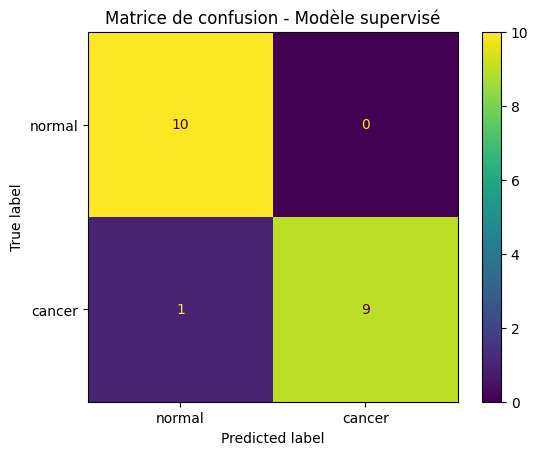

In [1527]:
ConfusionMatrixDisplay.from_predictions(
    y_true_sup,
    y_pred_sup,
    display_labels=["normal", "cancer"]
)

plt.title("Matrice de confusion - Modèle supervisé")
plt.show()

avant fine-tuning

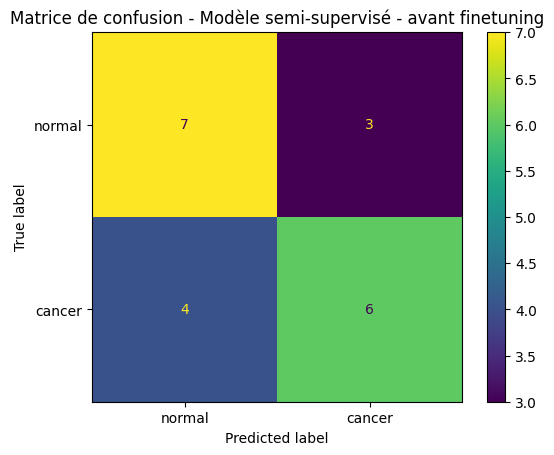

In [1528]:
ConfusionMatrixDisplay.from_predictions(
    y_true_before,
    y_pred_before,
    display_labels=["normal", "cancer"]
)

plt.title("Matrice de confusion - Modèle semi-supervisé - avant finetuning")
plt.show()

aprés fine-tuning

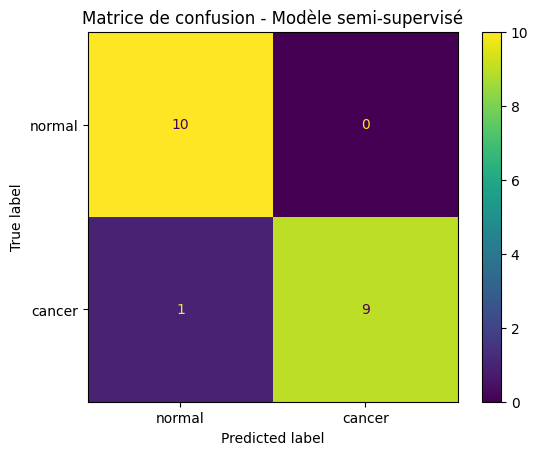

In [1529]:
ConfusionMatrixDisplay.from_predictions(
    y_true_semi,
    y_pred_semi,
    display_labels=["normal", "cancer"]
)

plt.title("Matrice de confusion - Modèle semi-supervisé")
plt.show()

8.12 Comparaison des performances

In [1530]:
comparison_df = pd.DataFrame([
    {
        "Approche": "Supervisée seule",
        **supervised_metrics
    },
    {
        "Approche": "Semi-supervisée avant fine-tuning",
        **semi_metrics_before
    },
    {
        "Approche": "Semi-supervisée après fine-tuning",
        **semi_metrics
    }
])

comparison_df

,Approche,accuracy,precision,recall,f1_score
0,Supervisée seule,0.95,1.000000,0.9,0.947368
1,Semi-supervisée avant fine-tuning,0.65,0.666667,0.6,0.631579
2,Semi-supervisée après fine-tuning,0.95,1.000000,0.9,0.947368


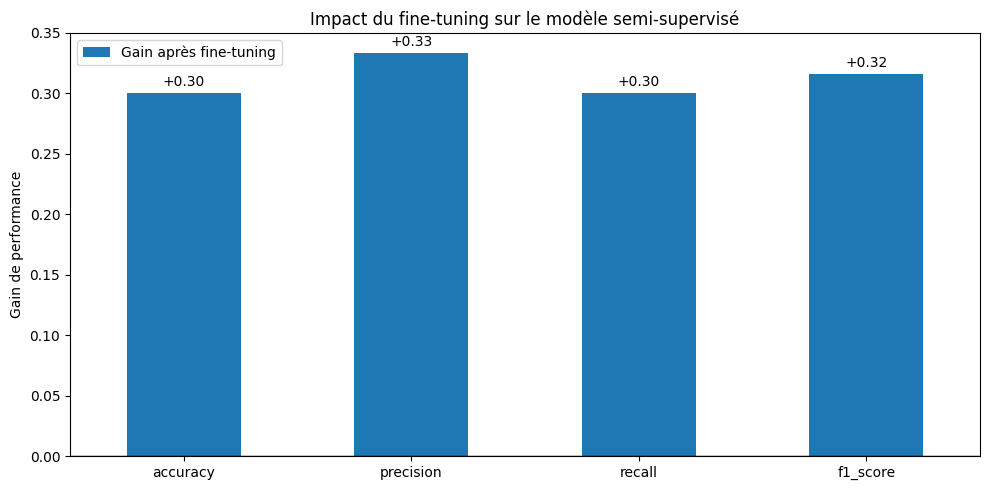

In [1531]:
metrics = ["accuracy", "precision", "recall", "f1_score"]

gain_finetuning = (
    pd.Series(semi_metrics)[metrics].astype(float)
    - pd.Series(semi_metrics_before)[metrics].astype(float)
)

gain_df = pd.DataFrame({
    "Gain après fine-tuning": gain_finetuning
})

ax = gain_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, color="black", linewidth=1)

ax.set_title("Impact du fine-tuning sur le modèle semi-supervisé")
ax.set_ylabel("Gain de performance")
ax.set_xticklabels(metrics, rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f", padding=3)

plt.tight_layout()
plt.show()

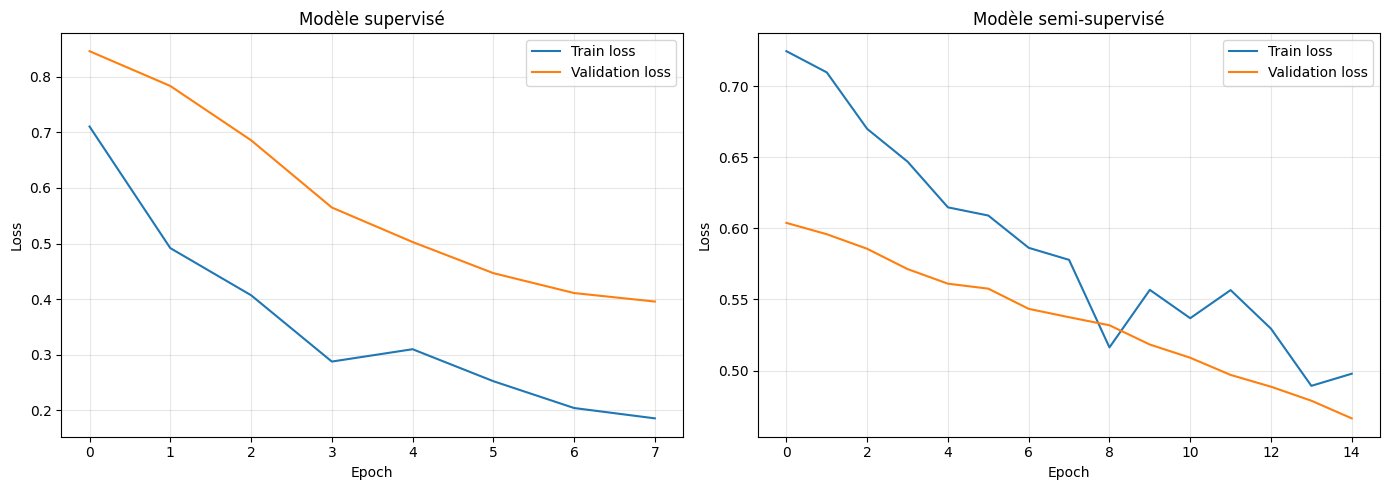

In [1532]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Modèle supervisé
# -------------------------

axes[0].plot(
    history_supervised["train_loss"],
    label="Train loss"
)

axes[0].plot(
    history_supervised["val_loss"],
    label="Validation loss"
)

axes[0].set_title("Modèle supervisé")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -------------------------
# Modèle semi-supervisé
# -------------------------

axes[1].plot(
    history_finetune["train_loss"],
    label="Train loss"
)

axes[1].plot(
    history_finetune["val_loss"],
    label="Validation loss"
)

axes[1].set_title("Modèle semi-supervisé")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

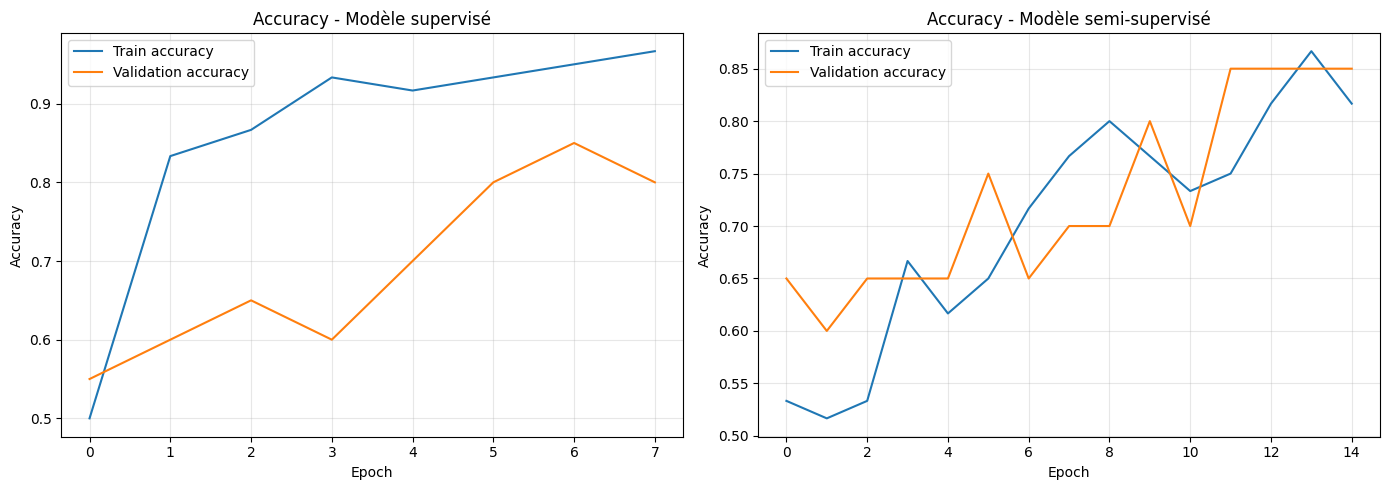

In [1533]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_supervised["train_accuracy"],
    label="Train accuracy"
)

axes[0].plot(
    history_supervised["val_accuracy"],
    label="Validation accuracy"
)

axes[0].set_title("Accuracy - Modèle supervisé")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_finetune["train_accuracy"],
    label="Train accuracy"
)

axes[1].plot(
    history_finetune["val_accuracy"],
    label="Validation accuracy"
)

axes[1].set_title("Accuracy - Modèle semi-supervisé")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1534]:
df_unlabeled_results.groupby(
    "profil_probable"
)["confiance_finale"].describe()

,count,mean,std,min,25%,50%,75%,max
profil_probable,,,,,,,,
cancer,786.0,0.597673,0.133577,0.0,0.521320,0.617689,0.689688,0.923077
normal,525.0,0.525618,0.142331,0.0,0.453978,0.549187,0.627988,0.823529


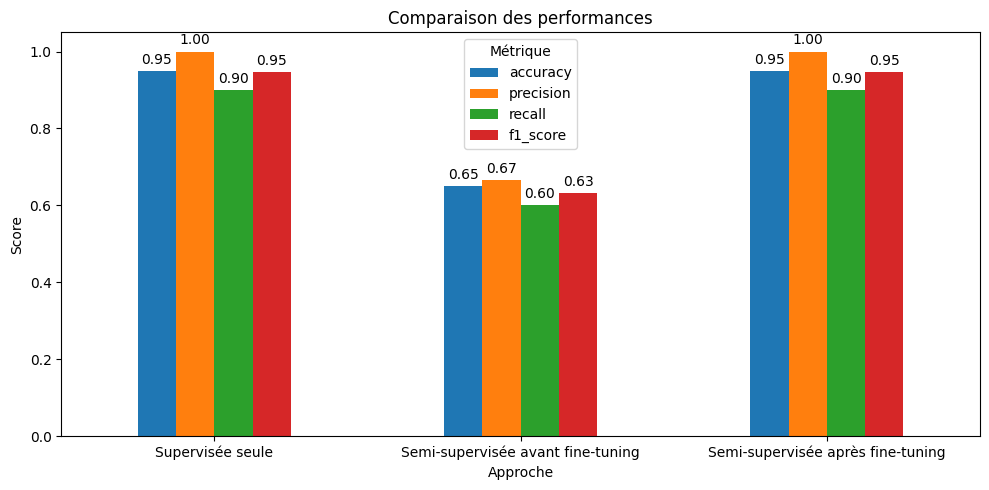

In [1535]:
# Visualisation des métriques

df_comparison_plot = comparison_df.set_index("Approche")

ax = df_comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison des performances")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métrique")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [1536]:
# Sauvegarde des résultats

comparison_df.to_csv(
    "../data/features/comparaison_supervise_semi_supervise.csv",
    index=False
)

print("Résultats sauvegardés.")

Résultats sauvegardés.


In [1537]:
# Prédire les probabilités sur les images non labellisées
def predict_proba_model(model, dataloader, device):
    model.eval()

    probabilities = []
    predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            cancer_probs = probs[:, 1]
            preds = torch.argmax(probs, dim=1)

            probabilities.extend(cancer_probs.cpu().numpy())
            predictions.extend(preds.cpu().numpy())

    return np.array(predictions), np.array(probabilities)

In [1538]:
unlabeled_dataset = BrainDataset(
    pd.concat(
        [train_unla_metadata, val_unla_metadata, test_unla_metadata],
        ignore_index=True
    ),
    transform=eval_transform
)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

unlabeled_preds, cancer_probabilities = predict_proba_model(
    supervised_model,
    unlabeled_loader,
    device
)

In [1539]:
unlabeled_dataset = BrainDataset(
    pd.concat(
        [train_unla_metadata, val_unla_metadata, test_unla_metadata],
        ignore_index=True
    ),
    transform=eval_transform
)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

unlabeled_preds, cancer_probabilities = predict_proba_model(
    supervised_model,
    unlabeled_loader,
    device
)

In [1540]:
unlabeled_metadata_all = pd.concat(
    [train_unla_metadata, val_unla_metadata, test_unla_metadata],
    ignore_index=True
)

df_detection_cancer = unlabeled_metadata_all.copy()

df_detection_cancer["prediction"] = unlabeled_preds
df_detection_cancer["probabilite_cancer"] = cancer_probabilities

df_detection_cancer["profil_predit"] = df_detection_cancer["prediction"].map({
    0: "normal",
    1: "cancer"
})

df_detection_cancer = df_detection_cancer.sort_values(
    "probabilite_cancer",
    ascending=False
)

df_detection_cancer.head(20)

,chemin,nom_fichier,classe,label,prediction,probabilite_cancer,profil_predit
1136,..\data\images_clean\sans_label\sans_label\7b4...,7b4c0b8b-e0b3-4b4b-b2fd-404824b3945c.jpg,sans_label,-1,1,0.985528,cancer
1089,..\data\images_clean\sans_label\sans_label\ac8...,ac865d09-397a-4949-9ebf-46ec9f12fa9c.jpg,sans_label,-1,1,0.985304,cancer
1011,..\data\images_clean\sans_label\sans_label\827...,827650e1-dd86-4dc9-a3e0-1483686c5c4d.jpg,sans_label,-1,1,0.985254,cancer
305,..\data\images_clean\sans_label\sans_label\5f3...,5f37b3dc-0a43-4369-9921-95d1c9aae781.jpg,sans_label,-1,1,0.984343,cancer
607,..\data\images_clean\sans_label\sans_label\ae1...,ae16d97e-2b19-4723-b545-5da8a6788538.jpg,sans_label,-1,1,0.983387,cancer
788,..\data\images_clean\sans_label\sans_label\ab1...,ab11abb6-af74-41ad-a11a-e7fa6d7291ba.jpg,sans_label,-1,1,0.983230,cancer
86,..\data\images_clean\sans_label\sans_label\95f...,95f9cab6-25fa-4b75-a824-d41b9e13bd61.jpg,sans_label,-1,1,0.982563,cancer
679,..\data\images_clean\sans_label\sans_label\cf3...,cf3c52af-5549-4f92-a57e-46de32e14e82.jpg,sans_label,-1,1,0.981728,cancer
1292,..\data\images_clean\sans_label\sans_label\b88...,b88a3666-f80f-4dc9-9857-dd86a147610d.jpg,sans_label,-1,1,0.980895,cancer
1235,..\data\images_clean\sans_label\sans_label\fce...,fced49dd-3752-42a0-a55c-03bc4e627614.jpg,sans_label,-1,1,0.980213,cancer


8 Conclusion